In [4]:
import random
def generateData(x):
    data_x = []
    data_y = []
    for i in range(x):
        x1 = random.randint(-5,5)
        x2 = random.randint(-5,5)
        if (x1+x2 > 0):
            data_x.append([x1,x2])
            data_y.append(2)
        elif(x1+x2 < 0):
            data_x.append([x1,x2])
            data_y.append(0)
        else:
            data_x.append([x1,x2])
            data_y.append(1)
    return data_x,data_y



In [5]:
train_x,train_y = generateData(60)
test_x,test_y = generateData(60)

In [6]:
train_x = [
    [0,0], [0,1], [1,0], [1,1]
]

train_y = [0,1,1,0]   # XOR pattern
from nn import MLP
from engine import Value
import random
model = MLP(2,[15,15,1])

beta_1 = 0.9
beta_2 = 0.999
lr = 0.1
eps = 1e-8

t = 1

data = list(zip(train_x,train_y))
batch_size = 2

m = [0 for _ in model.parameters()]
v = [0 for _ in model.parameters()]

for epoche in range(500):
    epoch_loss = 0
    random.shuffle(data)
    for batch_idx in range(0, len(data),batch_size):
        loss = Value(0)
        batch = data[batch_idx:batch_idx+batch_size]
        for x, y in batch:
            prob = model(x)[0]
            # y*log(p)
            term1 = y*prob.log()
            term2 = (1-y)*((1-prob)+ 0.0000001).log()
            loss -= term1 + term2
            
        reg_loss = Value(0)
        # L2 Regularization
        for p in model.parameters():
            reg_loss += p*p
        loss = loss + 0.01 * reg_loss
        loss.backward()

        # Momentum
        for i,p in enumerate(model.parameters()):
            # Momentum
            m[i] = beta_1*m[i] + (1-beta_1) * p.grad
            # Scaling
            v[i] = beta_2*v[i] + (1-beta_2) * (p.grad ** 2)
            # Bias Correction 
            
            m_hat = m[i] / (1 - beta_1**t)
            v_hat = v[i] / (1 - beta_2**t)

            # Update
            p.data += -lr*m_hat/(v_hat**0.5 + eps)
            p.grad = 0
        epoch_loss += loss
        t += 1
    print((epoch_loss * (1 / len(data))).data)

2.2370299900234505
1.1867448729117034
1.3993759466939346
1.0423999630871992
0.9475384448102627
0.9603485696281662
0.8959944346205075
0.9126418982105142
0.8871142051490777
0.8704451843718588
0.8452690903463747
0.8247045327582492
0.7886144983669481
0.7617565283174896
0.704536585166472
0.6693210690011329
0.6201335016014785
0.5502638740923467
0.5356715980400042
0.5085721278672852
0.4812951393608992
0.47434757145273526
0.45166902099518946
0.4185008042153978
0.3763147251405424
0.32964478643932826
0.28686708610812073
0.27557584061014406
0.2815628216589967
0.2621661406188124
0.26688129570724745
0.26472350653550825
0.2510803748504352
0.24205993690606836
0.23861636065346248
0.2328931082884764
0.2251505207850375
0.22359341115137762
0.21853985815019278
0.21210250645635226
0.20912618596140115
0.21051371986197098
0.21116116031004326
0.2050957880932867
0.20220508133282128
0.20558882471168405
0.20558789834985386
0.19781638435709475
0.19825411850662344
0.19846071542540028
0.19869342235921658
0.19739869

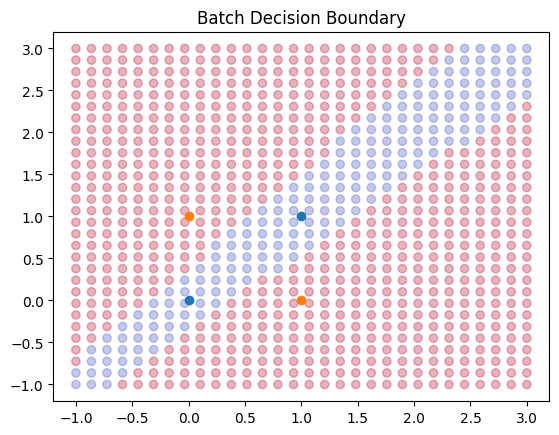

In [7]:
import numpy as np
grid = []
for x in np.linspace(-1,3,30):
    for y in np.linspace(-1,3,30):
        grid.append([x,y])
def predict(x):
    pred = model(x)[0].data
    return (1 if(pred>0.5) else 0)
pred = []
for point in grid:
    _pred = predict(point)
    pred.append(_pred)
import matplotlib.pyplot as plt

xs0 = [x[0] for x, y in zip(train_x, train_y) if y == 0]
ys0 = [x[1] for x, y in zip(train_x, train_y) if y == 0]

xs1 = [x[0] for x, y in zip(train_x, train_y) if y == 1]
ys1 = [x[1] for x, y in zip(train_x, train_y) if y == 1]

xs = [p[0] for p in grid]
ys = [p[1] for p in grid]

plt.scatter(xs, ys, c=pred, cmap='coolwarm', alpha=0.3)
plt.scatter(xs0, ys0)
plt.scatter(xs1, ys1)

plt.title("Batch Decision Boundary")
plt.show()

In [8]:
import random
temp = [[a,b] for a,b in zip(train_x,train_y)]
random.shuffle(temp)
print(temp)
train_x, train_y = map(list, zip(*temp))

[[[0, 1], 1], [[1, 1], 0], [[0, 0], 0], [[1, 0], 1]]


In [9]:
for x, y in zip(train_x,train_y):
        logits = model(x)[0]
        print(f'pred:{1 if(logits.data>0.5)else 0}, original:{y}')

pred:1, original:1
pred:0, original:0
pred:0, original:0
pred:1, original:1


####  MNIST

In [1]:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

mnist = fetch_openml('mnist_784',version=1)

X = mnist.data.astype(float).to_numpy() /255.0
y = mnist.target.astype(int).to_numpy()
train_x = X[:50]
train_y = y[:50]
# print(f'Shape of X:{X.shape}\nShape of y:{y}')

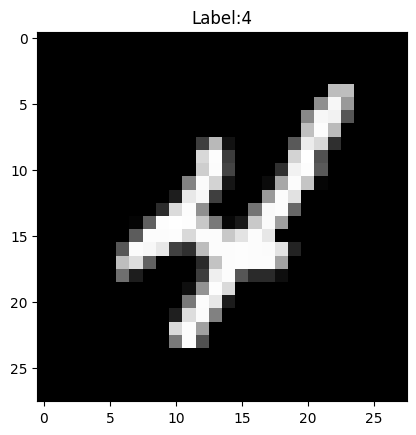

In [11]:
plt.imshow(X[9].reshape(28,28),cmap='gray')
plt.title(f"Label:{y[9]}")
plt.show()

In [2]:
def cross_entropy_logits(logits, y_true):
    max_logit = max(x.data for x in logits)
    exps = [(x-max_logit).exp() for x in logits]
    sum_exp = exps[0]
    for s in exps[1:]:
        sum_exp += s
    log_sum_exp = sum_exp.log() + max_logit

    return (log_sum_exp - logits[y_true])


In [ ]:
from nn import MLP
from engine import Value
import random
model = MLP(784,[32,10])
batch_size = 16
lr = 0.001

m = [0 for _ in model.parameters()]
v = [0 for _ in model.parameters()]
beta1 = 0.9
beta2 = 0.999
eps = 1e-8

t = 1
data = list(zip(X,y))
for epoch in range(3):
    random.shuffle(data)
    total_loss = 0
    for batch_idx in range(0,len(data),batch_size):
        batch = data[batch_idx:batch_idx+batch_size]
        loss = Value(0)
        for x,y_true in batch:
            logits = model(x)
            
            loss += cross_entropy_logits(logits,y_true)
        loss.backward()
        for j, p in enumerate(model.parameters()):
            m[j] = beta1*m[j] + (1-beta1) * p.grad
            v[j] = beta2*v[j] + (1-beta2) * (p.grad**2)

            m_hat = m[j]/(1-beta1**t)
            v_hat = v[j]/(1-beta2**t)
            p.data += -lr * m_hat / (v_hat**0.5 + eps)
            p.grad = 0
        total_loss += loss.data
        t += 1
    print(f"Epoch {epoch}, Loss:{total_loss/len(data)}")


In [3]:
train_x = X[:1000]
train_y = y[:1000]

test_x = X[1000:1200]
test_y = y[1000:1200]

import numpy as np

# Initialize parameters
w1 = np.random.randn(784, 128) * 0.01
b1 = np.zeros((1, 128))

w2 = np.random.randn(128, 10) * 0.01
b2 = np.zeros((1, 10))

lr = 0.1

for epoch in range(1000):

    # Forward pass
    h1 = train_x @ w1 + b1
    h1 = np.maximum(0, h1)  # ReLU

    logits = h1 @ w2 + b2

    exp_logits = np.exp(logits)
    probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

    # Loss
    correct_probs = probs[np.arange(len(train_x)), train_y]
    loss = -np.mean(np.log(correct_probs))

    # Backward pass
    dlogits = probs.copy()
    dlogits[np.arange(len(train_x)), train_y] -= 1
    dlogits = dlogits / len(train_x)

    dw2 = h1.T @ dlogits
    db2 = np.sum(dlogits, axis=0, keepdims=True)

    dh1 = dlogits @ w2.T
    dh1[h1 <= 0] = 0  # ReLU derivative

    dw1 = train_x.T @ dh1
    db1 = np.sum(dh1, axis=0, keepdims=True)

    # Parameter update
    w2 -= lr * dw2
    b2 -= lr * db2

    w1 -= lr * dw1
    b1 -= lr * db1

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 2.3023758488410278
Epoch 100, Loss: 0.8446097376553864
Epoch 200, Loss: 0.40455671859994163
Epoch 300, Loss: 0.28069273334034234
Epoch 400, Loss: 0.21216976463994724
Epoch 500, Loss: 0.16445128688930025
Epoch 600, Loss: 0.12876015977655939
Epoch 700, Loss: 0.1015264289972939
Epoch 800, Loss: 0.08075178572923693
Epoch 900, Loss: 0.06512129475067255


In [4]:
from Tensor_NN import MLP
from tensor import Tensor
import numpy as np
model = MLP()
def one_hot(y,num_classes=10):

    out = np.zeros((len(y),num_classes))

    out[np.arange(len(y)),y] = 1

    return out

In [5]:
for epoch in range(100):

    total_loss = 0

    for i in range(20):

        x = Tensor(train_x[i:i+1])

        target = Tensor(
            one_hot([train_y[i]])
        )

        logits = model(x)

        exp_logits = logits.exp()

        probs = exp_logits / exp_logits.sum()

        loss = -(
            target
            * probs.log()
        ).sum()

        # Zero gradients
        for p in model.parameters():
            p.grad = np.zeros_like(p.data)

        # Backpropagation
        loss.backward()

        # Gradient descent update
        lr = 0.01
        for p in model.parameters():
            p.data -= lr * p.grad

        total_loss += loss.data

    if epoch % 10 == 0:
        print(epoch, total_loss)

0 46.1498528566274
10 41.606036883060504
20 28.31164757099845
30 13.801055332757894
40 5.67725358122442
50 2.575974031821499
60 1.425540851473745
70 0.9235455726658629
80 0.6623759893544073
90 0.5078349895300635
